# Predictive Optimization for Term-Deposit Marketing

This notebook implements a two-stage analytical framework for term-deposit marketing decisions. Stage I estimates customer-level deposit amount, conversion probability, and withdrawal risk. Stage II uses those estimates in a mixed-integer optimization model to select APR and phone-call decisions that maximize expected EBIT under business constraints.


# IDS 586 Project: Predictive Optimization for Term-Deposit Marketing

**Team:** Tiange Yu, Michelle Schultze, Zirui Yan, Mingsheng Wang  
**Course:** IDS 586  
**Date:** May 2026

This notebook presents the complete empirical workflow for the term-deposit marketing project. It is organized as a reproducible analytical report: it states the business problem, prepares the data, estimates the required customer-level outcomes, constructs the optimization dataset, solves the decision problem, and summarizes the main outputs.

The goal is to translate customer-level campaign data into an actionable marketing strategy. The final output is a customer-level recommendation indicating whether a customer should be contacted and which APR offer should be assigned.

## 1. Executive Summary

The project studies how a retail bank can improve the profitability of term-deposit marketing campaigns. Instead of contacting customers broadly, the bank should target customers whose expected financial value is high after accounting for conversion probability, expected deposit amount, withdrawal risk, marketing cost, and operational cost.

The analysis follows a two-stage decision framework:

1. **Customer-level estimation.** The notebook estimates the key components of expected profitability: deposit amount, conversion probability, and withdrawal risk. Traditional statistical models are used for interpretability, while machine-learning models are evaluated as flexible predictive alternatives.

2. **Decision optimization.** The estimated outcomes are used to construct a customer-offer grid. A mixed-integer programming model then selects exactly one strategy for each customer, subject to budget and return-on-marketing constraints.

The final result is a decision-support pipeline that helps the bank move from blanket outreach to selective, profit-oriented customer targeting.

## 2. Setup and Configuration

This section imports the required packages, sets the random seed, and defines the file paths used throughout the analysis.

Before running the notebook, update `BASE_DIR` if the input data files are stored in a different folder.

**Required input file**

- `bank_marketing_refined_with_synth_apr (cleaned records).csv`

The notebook uses the processed dataset directly. The original `bank-full.csv` file is not required for this version.

**Main output files**

- `missing_by_column.csv`
- `t2_slice_sorted.csv`
- `synthesized_deposit_summary.csv`
- `deposit_model_comparison.csv`
- `conversion_model_evaluation_full.csv`
- `decision_grid_fixed.csv`
- `FINAL_OPTIMAL_OFFERS.csv`

These outputs allow the modeling results and optimization recommendations to be reviewed independently.

In [1]:
# Project paths
# Put the processed dataset in the data/ folder before running the notebook.
from pathlib import Path

PROJECT_ROOT = Path.cwd()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

processed_data_path = DATA_DIR / "bank_marketing_refined_with_synth_apr (cleaned records).csv"
output_dir = str(OUTPUT_DIR)

print("Project root:", PROJECT_ROOT)
print("Data file expected at:", processed_data_path)
print("Output folder:", output_dir)


Output directory: C:\Users\ryan1\OneDrive\Desktop\IDS
Processed dataset path: C:\Users\ryan1\OneDrive\Desktop\IDS\bank_marketing_refined_with_synth_apr (cleaned records).csv


## 3. Optimization Model Definition

This section defines the optimization function used later in the analysis. The model takes a customer-offer decision grid as input. Each row in the grid represents one feasible strategy for one customer, including the APR level, call decision, predicted conversion probability, predicted deposit amount, expected withdrawal rate, marketing cost, operational cost, and expected EBIT.

The optimization problem maximizes total expected EBIT subject to three main requirements:

1. **Exclusive choice:** each customer receives exactly one strategy.
2. **Marketing budget:** total phone-call spending cannot exceed the campaign budget.
3. **Return-on-marketing:** total expected EBIT must exceed the required return threshold relative to marketing cost.

No-call alternatives are assigned zero EBIT so that the optimization model does not create artificial profit from customers who are not actively targeted.

In [2]:
def run_optimization_pipeline(input_df):
    """
    Main function to run the MIP optimization and generate plots.
    
    Parameters:
    input_df (pd.DataFrame): The Decision Grid generated by Stage I.
                             Must contain columns: id, call, EBIT, MC, APR, etc.
    
    Returns:
    tuple: (final_solution_df, EBIT_matrix, APR_matrix)
    """
    
    # Create a working copy to avoid modifying the original DataFrame
    df = input_df.copy()
    
    # ---------------------------------------------------
    # PREPROCESSING: zero-out EBIT for no-call strategies
    # ---------------------------------------------------
    df.loc[df["call"] == 0, "EBIT"] = 0
    
    # Basic vetting (Optional: You can comment these out in production)
    print("\n" + "="*50)
    print("STAGE II: OPTIMIZATION STARTED")
    print("="*50)
    print("Input Data Shape:", df.shape)
    print("\nSample Columns:", df.columns.tolist()[:10], "...")

    # ---------------------------------------------------
    # PARAMETERS & VARIABLES
    # ---------------------------------------------------
    # These can be made flexible later. For now, keeping them as per your spec.
    CPC = 0.75 
    B = 5500 
    eta = 1.5 

    # Binary choice variable for each feasible customer-offer row
    x = LpVariable.dicts("x", df.index, cat="Binary")

    # MIP problem
    prob = LpProblem("Bank_Offer_Optimization", LpMaximize)

    # ---------------------------------------------------
    # OBJECTIVE FUNCTION
    # ---------------------------------------------------
    # Objective: maximize total EBIT
    prob += lpSum(df.loc[i, "EBIT"] * x[i] for i in df.index)

    # ---------------------------------------------------
    # CONSTRAINTS
    # ---------------------------------------------------
    # 1. Each customer gets exactly one offer
    for cust_id, rows in df.groupby("id").groups.items():
        prob += lpSum(x[i] for i in rows) == 1

    # 2. Marketing budget constraint
    prob += lpSum(df.loc[i, "call"] * CPC * x[i] for i in df.index) <= B

    # 3. Return-on-marketing (ROM) constraint
    prob += (
        lpSum(df.loc[i, "EBIT"] * x[i] for i in df.index)
        >= eta * lpSum(df.loc[i, "MC"] * x[i] for i in df.index)
    )

    # ---------------------------------------------------
    # SOLVE
    # ---------------------------------------------------
    print("\nSolving Optimization Problem...")
    prob.solve()
    
    # Extract the chosen rows (The final offer list)
    solution = df[[x[i].value() == 1 for i in df.index]]

    # ---------------------------------------------------
    # PRINT RESULTS
    # ---------------------------------------------------
    print("\n" + "-"*30)
    print("OPTIMIZATION RESULTS")
    print("-"*30)
    print("Total EBIT:", value(prob.objective))
    print("Total Calls:", solution["call"].sum())
    print("Total Marketing Spend:", (solution["call"] * CPC).sum())
    if solution["MC"].sum() > 0:
        print("ROM:", solution["EBIT"].sum() / solution["MC"].sum())
    else:
        print("ROM: N/A (No Marketing Cost)")

    # ---------------------------------------------------
    # PLOT 1: APR Assignment Distribution
    # ---------------------------------------------------
    # Split into call vs no-call
    solution_call = solution[solution["call"] == 1]
    solution_nocall = solution[solution["call"] == 0]
    
    # Handle NA for no-call
    if not solution_call.empty:
        apr_counts = solution_call["APR"].value_counts().sort_index()
    else:
        apr_counts = pd.Series(dtype=int)
        
    # Add NA count for no-call customers
    apr_counts.loc["NA"] = len(solution_nocall)
    
    # Reindex to ensure NA is first
    if not apr_counts.empty:
        apr_counts.index = apr_counts.index.astype(str)
        apr_levels = sorted([idx for idx in apr_counts.index if idx != "NA"], key=lambda x: float(x))
        apr_counts = apr_counts.reindex(["NA"] + apr_levels)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(apr_counts.index.astype(str), apr_counts.values)
    
    for i, v in enumerate(apr_counts.values):
        plt.text(i, v, str(v), ha="center", va="bottom")
    
    plt.xlabel("APR Level (including NA for no call)")
    plt.ylabel("Number of Customers")
    plt.title("APR Assignment Distribution (Original Parameters)")
    plt.show()

    # ---------------------------------------------------
    # GRID SEARCH: Sensitivity Analysis
    # ---------------------------------------------------
    print("\nRunning Sensitivity Analysis (Grid Search)...")
    
    # Parameters
    B_grid = [250, 500, 750, 1000, 1250, 1500, 2000, 4000, 6000, 8000, 10000]
    eta_grid = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
    
    APR_call_mat = np.zeros((len(eta_grid), len(B_grid)))
    EBIT_mat = np.zeros((len(eta_grid), len(B_grid)))

    # Solver settings to speed up (as per your original code)
    solver = PULP_CBC_CMD(msg=False, gapRel=0.0005, timeLimit=60)

    # Nested loops
    for i, eta in enumerate(eta_grid):
        for j, B in enumerate(B_grid):
            # --- Re-define the problem inside the loop ---
            x_temp = LpVariable.dicts("x", df.index, cat="Binary")
            prob_temp = LpProblem("Bank_Offer_Optimization", LpMaximize)
            
            # Objective
            prob_temp += lpSum(df.loc[k, "EBIT"] * x_temp[k] for k in df.index)
            
            # Constraints
            # 1. One offer per customer
            for cust_id, rows in df.groupby("id").groups.items():
                prob_temp += lpSum(x_temp[k] for k in rows) == 1
                
            # 2. Budget
            prob_temp += lpSum(df.loc[k, "call"] * CPC * x_temp[k] for k in df.index) <= B
            
            # 3. ROM
            prob_temp += (lpSum(df.loc[k, "EBIT"] * x_temp[k] for k in df.index) 
                         >= eta * lpSum(df.loc[k, "MC"] * x_temp[k] for k in df.index))
            
            # Solve
            prob_temp.solve(solver)
            
            # Store EBIT
            EBIT_mat[i, j] = value(prob_temp.objective)
            
            # Calculate Avg APR for calls
            total_call = 0
            total_apr_call = 0
            for k in df.index:
                if x_temp[k].value() > 0.5: # If selected
                    if df.loc[k, "call"] == 1: # If it's a call
                        total_call += 1
                        total_apr_call += df.loc[k, "APR"]
            
            if total_call > 0:
                APR_call_mat[i, j] = total_apr_call / total_call
            else:
                APR_call_mat[i, j] = np.nan

    # ---------------------------------------------------
    # PLOT 2: EBIT Heatmap
    # ---------------------------------------------------
    plt.figure(figsize=(12, 8))
    EBIT_plot = EBIT_mat.copy()
    EBIT_plot[EBIT_plot < 0] = np.nan
    
    plt.imshow(EBIT_plot, aspect="auto", cmap="viridis")
    
    plt.xticks(range(len(B_grid)), B_grid, fontsize=9, rotation=45)
    plt.yticks(range(len(eta_grid)), eta_grid, fontsize=9)
    
    plt.xlabel("Budget Constraint (B)")
    plt.ylabel("ROM threshold (η)")
    plt.title("Total EBIT Across Constraint Grid")
    
    # Add text labels
    for i in range(len(eta_grid)):
        for j in range(len(B_grid)):
            val = EBIT_mat[i, j]
            if val < 0 or np.isnan(val):
                label = "NA"
            else:
                label = f"{val:.0f}"
            plt.text(j, i, label, ha="center", va="center", color="white", fontsize=8)
    
    plt.colorbar(label="EBIT")
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # PLOT 3: Average APR Heatmap
    # ---------------------------------------------------
    plt.figure(figsize=(12, 8))
    APR_plot = APR_call_mat.copy()
    # Mask APR wherever EBIT is negative/invalid
    APR_plot[EBIT_mat < 0] = np.nan
    
    plt.imshow(APR_plot, aspect="auto", cmap="plasma")
    
    plt.xticks(range(len(B_grid)), B_grid, fontsize=9, rotation=45)
    plt.yticks(range(len(eta_grid)), eta_grid, fontsize=9)
    
    plt.xlabel("Budget Constraint (B)")
    plt.ylabel("ROM threshold (η)")
    plt.title("Average APR Across Constraint Grid")
    
    # Add text labels
    for i in range(len(eta_grid)):
        for j in range(len(B_grid)):
            val = APR_plot[i, j]
            if np.isnan(val):
                label = "NA"
            else:
                label = f"{val:.2f}"
            plt.text(j, i, label, ha="center", va="center", color="white", fontsize=8)
    
    plt.colorbar(label="Avg APR for Call=1")
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # RETURN RESULTS
    # ---------------------------------------------------
    # This sends data back to Stage I for saving
    return solution, EBIT_mat, APR_call_mat

# ---------------------------------------------------
# END OF FILE
# ---------------------------------------------------


## 4. Helper Functions and Statistical Models

This section defines reusable functions and model classes used in the empirical analysis.

The main components are:

- withdrawal-ratio calculation,
- summary-statistics generation,
- Tobit likelihood estimation for censored deposit amounts,
- expected-value prediction for the Tobit model,
- regression and classification evaluation metrics.

These functions support the estimation and reporting steps in the following sections.

In [3]:
def calc_withdrawal_ratio(balance, gamma, C):
    if balance <= 0:
        return 1.0
    else:
        return max(gamma, min(1.0, C / balance))

def summarize_deposits(df, output_filepath):
    summary_dict = {}
    essential_metrics = ['count', 'mean', 'median', 'min', 'max']

    if 'latent_deposit' in df.columns:
        summary_dict['Latent_Deposit (Raw)'] = df['latent_deposit'].agg(essential_metrics)
        print("\n-- Latent Deposit Summary --")
        print(summary_dict['Latent_Deposit (Raw)'].round(2))

    if 'deposit_amount' in df.columns:
        summary_dict['All_Deposit_Amounts (Includes 0s)'] = df['deposit_amount'].agg(essential_metrics)
        print("\n-- Actual Deposit Amount (Includes 0s) --")
        print(summary_dict['All_Deposit_Amounts (Includes 0s)'].round(2))
        
        positive_deposits = df[df['deposit_amount'] > 0]['deposit_amount']
        summary_dict['Positive_Deposits_Only (> 0)'] = positive_deposits.agg(essential_metrics)
        print("\n-- Positive Deposit Amount (> 0) --")
        print(summary_dict['Positive_Deposits_Only (> 0)'].round(2))

    if summary_dict:
        summary_df = pd.DataFrame(summary_dict).round(2)
        summary_df.to_csv(output_filepath)
        return summary_df
    else:
        return None

def create_summary_table(data, name):
    summary_rows = []
    for col in data.columns:
        series = data[col]

        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            col_type = "numeric"
        elif pd.api.types.is_bool_dtype(series):
            col_type = "boolean"
        else:
            col_type = "categorical"

        n_missing = series.isna().sum()
        sample_vals = series.dropna().unique()[:5]
        sample_vals_str = ", ".join(map(str, sample_vals))

        mean = var = q25 = q50 = q75 = None
        if col_type == "numeric":
            mean = series.mean()
            var = series.var()
            q25 = series.quantile(0.25)
            q50 = series.quantile(0.50)
            q75 = series.quantile(0.75)

        summary_rows.append({
            "Variable": col,
            "Type": col_type,
            "Missing_Values": n_missing,
            "Mean": mean,
            "Variance": var,
            "25th_Percentile": q25,
            "Median": q50,
            "75th_Percentile": q75,
            "Sample_Values": sample_vals_str
        })

    summary_df = pd.DataFrame(summary_rows)
    file_path = f"{output_dir}/summary_stats_{name}.csv"
    summary_df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")
    return summary_df

class Tobit(GenericLikelihoodModel):
    def loglike(self, params):
        y = self.endog
        X = self.exog
        beta = params[:-1]
        sigma = params[-1]
        mu = np.dot(X, beta)
        ll_censored = np.log(1 - norm.cdf(mu[y == 0] / sigma) + 1e-10)
        ll_uncensored = np.log(norm.pdf((y[y > 0] - mu[y > 0]) / sigma) / sigma + 1e-10)
        return np.sum(ll_censored) + np.sum(ll_uncensored)

def predict_expected_deposit(X_matrix, beta, sigma):
    mu = np.dot(X_matrix, beta)
    prob_uncensored = norm.cdf(mu / sigma)
    pdf_val = norm.pdf(mu / sigma)
    expected_value = prob_uncensored * mu + sigma * pdf_val
    return expected_value

def evaluate_regression(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"--- {dataset_name} Performance ---")
    print(f"Mean Absolute Error (MAE):   ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

def evaluate_model(model, df, target_col, threshold=0.5):
    probs = model.predict(df)
    classes = (probs >= threshold).astype(int)
    actuals = df[target_col]
    return {
        "AUC": roc_auc_score(actuals, probs),
        "Accuracy": accuracy_score(actuals, classes),
        "Log Loss": log_loss(actuals, probs),
    }

def eval_reg(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def tobit_expected_value(X, beta, sigma):
    mu = X @ beta
    z = mu / sigma
    Phi = norm.cdf(z)
    phi = norm.pdf(z)
    return Phi * mu + sigma * phi

# =========================================================
# MAIN EXECUTION LOGIC
# =========================================================


## 5. Empirical Analysis and Stage I Estimation

This section prepares the customer-level dataset and estimates the key quantities needed for the optimization model.

The workflow includes:

1. **Data loading and missing-value review.** The original and refined banking datasets are loaded, cleaned, and summarized.

2. **Customer segmentation for withdrawal risk.** K-Means clustering assigns customers to low-, medium-, and high-liquidity-risk groups. These groups are mapped to withdrawal probabilities and expected withdrawal rates.

3. **Decision-sample construction.** The panel-style contact history is converted into a `t = 2` cross-sectional decision sample, representing the customer pool eligible for follow-up contact.

4. **Synthetic deposit amount construction.** Because actual deposit amounts are not directly observed, a synthetic deposit data-generating process is constructed using account balance, APR, call status, age, and random noise.

5. **Deposit amount estimation.** A Tobit-style censored regression estimates expected deposit amount, and machine-learning alternatives are evaluated against the traditional statistical model.

6. **Conversion probability estimation.** Logistic regression and machine-learning classifiers estimate customer conversion probability.

7. **Decision-grid construction.** For each customer, APR level, and call/no-call option, the notebook calculates predicted deposit amount, predicted conversion probability, expected withdrawal rate, marketing cost, operational cost, and EBIT.

This section produces the decision grid used in the optimization stage.

In [4]:
def main():
    # =========================================================
    # LOAD PROCESSED DATA
    # =========================================================
    # Dataset path is configured in the notebook setup cell.
    # This version uses the processed dataset directly and does not require bank-full.csv.

    df_new = pd.read_csv(new_path)

    # Standardize missing values
    df_new.replace("unknown", np.nan, inplace=True)

    df = df_new.copy()

    # =========================================================
    # (1) MISSINGNESS — ORIGINAL DF
    # =========================================================
    summary_missing = []
    for col in df.columns:
        n_missing = df[col].isna().sum()
        total_rows = len(df[col])
        frac_missing = n_missing / total_rows
        summary_missing.append({
            "Variable": col,
            "Missing_Values": n_missing,
            "Total_Rows": total_rows,
            "Fraction_Missing": frac_missing
        })

    missing_by_col = pd.DataFrame(summary_missing)
    missing_by_col.to_csv(f"{output_dir}/missing_by_column.csv", index=False)
    print("Saved:", f"{output_dir}/missing_by_column.csv")

    df["has_missing"] = df.isna().any(axis=1)
    total_by_t = df.groupby("campaign").size().reset_index(name="Total_Rows")

    rows = []
    for t, group in df.groupby("campaign"):
        n_rows_with_missing = group["has_missing"].sum()
        fraction_missing = n_rows_with_missing / len(group)
        missing_counts_bin = group.isna().sum()
        
        if missing_counts_bin.max() > 0:
            max_missing_col = missing_counts_bin.idxmax()
            max_missing_val = missing_counts_bin.max()
            max_missing_frac = max_missing_val / len(group)
        else:
            max_missing_col = None
            max_missing_val = 0
            max_missing_frac = 0.0
        
        cols_with_missing = missing_counts_bin[missing_counts_bin > 0].index.tolist()
        cols_with_missing_str = ", ".join(cols_with_missing) if cols_with_missing else ""
        
        rows.append({
            "Number_of_Calls": t,
            "Rows_With_Missing_Values": n_rows_with_missing,
            "Total_Rows": len(group),
            "Fraction_Missing": fraction_missing,
            "Column_With_Max_Missing": max_missing_col,
            "Max_Missing_Count": max_missing_val,
            "Max_Missing_Fraction": max_missing_frac,
            "Columns_With_Missing_Values": cols_with_missing_str
        })

    missing_by_t = pd.DataFrame(rows)
    missing_by_t.to_csv(f"{output_dir}/missing_rows_by_num_calls.csv", index=False)
    print(f"Saved missing-by-calls table to: {output_dir}/missing_rows_by_num_calls.csv")

    # =========================================================
    # (2) CALL DISTRIBUTION
    # =========================================================
    call_counts = df["campaign"].value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    ax = call_counts.plot(kind="bar")
    plt.xlabel("Number of times called")
    plt.ylabel("Number of customers")
    plt.title("Distribution of Number of Calls per Customer")

    for i, v in enumerate(call_counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/call_distribution.png")
    plt.close()

    # =========================================================
    # LIQUIDITY RISK SEGMENTATION & WITHDRAWAL ESTIMATION
    # =========================================================
    print("Running K-Means for liquidity risk segmentation...")
    risk_features = ["age", "job", "marital", "education", "default", "balance", "housing", "loan"]
    df_risk = df[risk_features].copy()

    cat_cols = ["job", "marital", "education", "default", "housing", "loan"]
    df_risk_encoded = pd.get_dummies(df_risk, columns=cat_cols, drop_first=True)

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_risk_encoded)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["risk_cluster"] = kmeans.fit_predict(scaled_features)

    cluster_means = df.groupby("risk_cluster")["balance"].mean().sort_values()
    risk_mapping = {
        cluster_means.index[0]: "High Risk",
        cluster_means.index[1]: "Medium Risk",
        cluster_means.index[2]: "Low Risk"
    }
    df["liquidity_risk_level"] = df["risk_cluster"].map(risk_mapping)

    pw_mapping = {
        "High Risk": 0.30,
        "Medium Risk": 0.15,
        "Low Risk": 0.05
    }
    df["p_w"] = df["liquidity_risk_level"].map(pw_mapping)

    gamma = 0.10  
    C = 500      
    df["exp_ratio"] = df["balance"].apply(lambda b: calc_withdrawal_ratio(b, gamma, C))
    df["expected_withdrawal_rate"] = df["p_w"] * df["exp_ratio"]

    print("Liquidity segmentation and withdrawal estimation complete.")

    segment_counts = df["liquidity_risk_level"].value_counts()
    segment_props = df["liquidity_risk_level"].value_counts(normalize=True) * 100
    distribution_summary = pd.DataFrame({"Count": segment_counts, "Percentage (%)": segment_props.round(2)})
    print("\n1. Customer Distribution by liquidity Level:")
    print(distribution_summary)

    profile_features = ["age", "balance", "p_w", "exp_ratio", "expected_withdrawal_rate"]
    cluster_profile = df.groupby("liquidity_risk_level")[profile_features].mean().round(4)
    cluster_profile = cluster_profile.reindex(["High Risk", "Medium Risk", "Low Risk"])

    print("\n2. Average Customer Profile per liquidity Level:")
    print(cluster_profile)

    distribution_summary.to_csv(f"{output_dir}/liquidity_risk_distribution.csv")
    cluster_profile.to_csv(f"{output_dir}/liquidity_risk_profiles.csv")

    # =========================================================
    # BUILD DISAGGREGATED DATA
    # =========================================================
    max_calls = df["campaign"].max()
    rows_disagg = []

    for idx, row in df.iterrows():
        n_calls = row["campaign"]
        converted = 1 if row["y"] == "yes" else 0
        
        for t in range(1, max_calls + 1):
            bank_action = 1 if t <= n_calls else 0
            
            if t > n_calls:
                deposit = np.nan
            elif t == n_calls:
                deposit = converted
            else:
                deposit = 0
            
            rows_disagg.append({
                "id": idx,
                "t": t,
                "bank_action": bank_action,
                "term_deposit_decision": deposit,
                "age": row["age"],
                "job": row["job"],
                "marital": row["marital"],
                "education": row["education"],
                "default": row["default"],
                "balance": row["balance"],
                "housing": row["housing"],
                "loan": row["loan"],
                "contact": row["contact"],
                "day": row["day"],
                "month": row["month"],
                "duration": row["duration"],
                "campaign": row["campaign"],
                "pdays": row["pdays"],
                "previous": row["previous"],
                "poutcome": row["poutcome"],
                "liquidity_risk_level": row["liquidity_risk_level"],
                "expected_withdrawal_rate": row["expected_withdrawal_rate"],
                "y": row["y"],
                "APR": row["APR"] if "APR" in row else np.nan
            })

    disaggregated_df = pd.DataFrame(rows_disagg)

    # ===============================================================================
    # SYNTHESIZE DATA GENERATING PROCESS (DGP) OF CUSTOMER DEPOSIT AMOUNT
    # ===============================================================================
    noise = np.random.normal(0, 1000, size=len(disaggregated_df))
    temp_apr = disaggregated_df["APR"].fillna(disaggregated_df["APR"].median())

    disaggregated_df["latent_deposit"] = (
        -2500 
        + 0.15 * disaggregated_df["balance"] 
        + 500 * temp_apr 
        + 800 * disaggregated_df["bank_action"] 
        + 12 * disaggregated_df["age"] 
        + noise
    )
    disaggregated_df["deposit_amount"] = np.maximum(0, disaggregated_df["latent_deposit"])

    # =========================================================
    # (3A) TERM DEPOSIT DISTRIBUTION — DISAGGREGATED
    # =========================================================
    # Keep the numeric outcome column unchanged for later modeling.
    # Use a separate object-type column only for plotting labels.
    disaggregated_df["term_deposit_decision_cat"] = (
        disaggregated_df["term_deposit_decision"]
        .astype("object")
        .where(disaggregated_df["term_deposit_decision"].notna(), "NA")
    )

    grouped = disaggregated_df.groupby(["t", "term_deposit_decision_cat"]).size().unstack(fill_value=0)
    top = grouped.loc[grouped.index <= 31]
    bottom = grouped.loc[grouped.index > 31]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    ax1 = top.plot(kind="bar", ax=axes[0])
    axes[0].set_title("t = 1–31")

    for container in ax1.containers:
        for bar in container:
            if bar.get_height() > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()),
                         ha='center', va='bottom', fontsize=6)

    if not bottom.empty:
        ax2 = bottom.plot(kind="bar", ax=axes[1])
        axes[1].set_title("t = 32–63")
        for container in ax2.containers:
            for bar in container:
                height = bar.get_height()
                if height > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2, height, int(height), ha='center', va='bottom', fontsize=6)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/term_deposit_distribution_disaggregateddata.png")
    plt.close()

    # =========================================================
    # (3B) TERM DEPOSIT DISTRIBUTION — ORIGINAL DF
    # =========================================================
    df["term_deposit_cat"] = df["y"].map({"yes": 1, "no": 0})
    grouped_df = df.groupby(["campaign", "term_deposit_cat"]).size().unstack(fill_value=0)

    plt.figure(figsize=(14, 6))
    ax = grouped_df.plot(kind="bar")
    for container in ax.containers:
        for bar in container:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()),
                        ha='center', va='bottom', fontsize=6)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/term_deposit_distribution_original.png")
    plt.close()

    # =========================================================
    # (4) CORRELATION HEATMAP
    # =========================================================
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    cat_to_encode = [col for col in categorical_cols if df[col].nunique(dropna=True) <= 10]

    df_encoded = pd.get_dummies(df[numeric_cols + cat_to_encode], drop_first=True)
    corr_matrix = df_encoded.corr()

    plt.figure(figsize=(14, 12))
    im = plt.imshow(corr_matrix, vmin=-1, vmax=1)
    plt.colorbar(im)
    plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=6)
    plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, fontsize=6)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/correlation_heatmap.png")
    plt.close()

    disaggregated_df.to_csv(f"{output_dir}/bank_disaggregated_long.csv", index=False)
    print("All outputs saved to:", output_dir)

    summary_original = create_summary_table(df, "original")
    summary_disaggregated = create_summary_table(disaggregated_df, "disaggregated")

    print("Unique campaign values:", sorted(df['campaign'].unique()))
    print("Min campaign value:", df['campaign'].min())

    # =========================================================
    # (5) FILTER t = 2 SLICE + SAVE
    # =========================================================
    t2_df = disaggregated_df[disaggregated_df["t"] == 2].copy()
    t2_df_sorted = t2_df.sort_values(by=["id", "campaign"])

    t2_path = f"{output_dir}/t2_slice_sorted.csv"
    t2_df_sorted.to_csv(t2_path, index=False)
    print(f"Saved t=2 slice to: {t2_path}")

    crucial_cols = ['age', 'balance', 'previous', 'pdays', 'campaign', 'duration', 'APR']
    corr_df = t2_df_sorted[crucial_cols]
    corr_matrix_slice = corr_df.corr(method='pearson')

    # Correlation heatmap using matplotlib only, so the notebook does not require seaborn.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_matrix_slice.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(np.arange(len(corr_matrix_slice.columns)))
    ax.set_yticks(np.arange(len(corr_matrix_slice.index)))
    ax.set_xticklabels(corr_matrix_slice.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix_slice.index)

    for row_idx in range(corr_matrix_slice.shape[0]):
        for col_idx in range(corr_matrix_slice.shape[1]):
            value = corr_matrix_slice.iloc[row_idx, col_idx]
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Pearson Correlation Coefficient")
    ax.set_title("Correlation Heatmap of Key Variables")
    plt.tight_layout()
    output_filename = f"{output_dir}/sliced_correlation_heatmap.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"\n✅ Sliced correlation heatmap saved to: {output_filename}")

    summary_t2 = create_summary_table(t2_df_sorted, "t2_slice")
    print("Done with t=2 exports.")

    # =========================================================
    # DEPOSIT ESTIMATION - TSM
    # =========================================================
    df_t2 = t2_df_sorted.copy()
    Y = df_t2['deposit_amount']
    X = df_t2[['balance', 'APR', 'bank_action', 'age']]
    X = sm.add_constant(X)

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    ols_fit_train = sm.OLS(Y_train, X_train).fit()
    sigma_guess = np.sqrt(ols_fit_train.scale)
    start_params = np.append(ols_fit_train.params.values, sigma_guess)

    tobit_model = Tobit(Y_train, X_train)
    tobit_results = tobit_model.fit(start_params=start_params, method='bfgs', maxiter=1000, disp=0)

    print(tobit_results.summary())
    beta = tobit_results.params[:-1]
    sigma = tobit_results.params[-1]

    pred_train = predict_expected_deposit(X_train, beta, sigma)
    pred_test  = predict_expected_deposit(X_test, beta, sigma)

    print("TOBIT MODEL ESTIMATED DEPOSIT AMOUNT EVALUATION\n" + "="*45)
    evaluate_regression(Y_train, pred_train, "In-Sample (Training)")
    evaluate_regression(Y_test, pred_test, "Out-of-Sample (Testing)")

    # =========================================================
    # CONVERSION ESTIMATION - TSM
    # =========================================================
    conv_t2 = t2_df_sorted.copy()
    called_t2 = conv_t2[(conv_t2["bank_action"] == 1) & (conv_t2["term_deposit_decision"].notna())].copy()
    called_t2["event"] = called_t2["term_deposit_decision"].astype(int)
    called_t2["APR"] = called_t2["APR"].fillna(called_t2["APR"].median())
    called_t2["balance_clean"] = called_t2["balance"].fillna(0).clip(lower=0)
    called_t2["log_balance"] = np.log1p(called_t2["balance_clean"])
    called_t2["poutcome_clean"] = called_t2["poutcome"].fillna("unknown").astype(str)
    called_t2["prior_success"] = (called_t2["poutcome_clean"] == "success").astype(int)

    model_df = called_t2[["event", "APR", "log_balance", "prior_success"]].dropna().copy()
    train_df, test_df = train_test_split(model_df, test_size=0.30, random_state=42, stratify=model_df["event"])

    conversion_formula = "event ~ APR + log_balance + prior_success"
    conversion_model = smf.glm(formula=conversion_formula, data=train_df, family=sm.families.Binomial()).fit()

    print("\n=== Conversion Model ===")
    print(conversion_model.summary())

    with open(f"{output_dir}/conversion_model_training_summary.txt", "w") as f:
        f.write(conversion_model.summary().as_text())

    train_metrics = evaluate_model(conversion_model, train_df, "event")
    test_metrics = evaluate_model(conversion_model, test_df, "event")

    evaluation_df = pd.DataFrame({"Metric": train_metrics.keys(), "Train": train_metrics.values(), "Test": test_metrics.values()})
    evaluation_df["Gap (Abs)"] = (evaluation_df["Train"] - evaluation_df["Test"]).abs()
    print("\n=== Model Evaluation Comparison ===")
    print(evaluation_df)
    evaluation_df.to_csv(f"{output_dir}/conversion_model_evaluation_full.csv", index=False)

    baseline_df = conv_t2.copy()
    baseline_df["poutcome_clean"] = baseline_df["poutcome"].fillna("unknown").astype(str)
    baseline_df["balance_clean"] = baseline_df["balance"].fillna(0).clip(lower=0)

    q33 = baseline_df["balance_clean"].quantile(0.33)
    q67 = baseline_df["balance_clean"].quantile(0.67)

    def balance_bucket_fn(x):
        if x <= q33: return "low"
        elif x <= q67: return "mid"
        else: return "high"

    baseline_df["balance_bucket"] = baseline_df["balance_clean"].apply(balance_bucket_fn)
    base_by_poutcome = {"success": 0.025, "failure": 0.008, "other": 0.006, "unknown": 0.004}
    baseline_df["base_poutcome"] = baseline_df["poutcome_clean"].map(base_by_poutcome).fillna(0.004)
    balance_adj_map = {"low": 0.000, "mid": 0.002, "high": 0.004}
    baseline_df["base_balance_adj"] = baseline_df["balance_bucket"].map(balance_adj_map)
    baseline_df["p_base_no_call"] = (baseline_df["base_poutcome"] + baseline_df["base_balance_adj"]).clip(lower=0.002, upper=0.060)

    print("\n=== Baseline No-Call Conversion Probability Summary ===")
    print(baseline_df["p_base_no_call"].describe())
    baseline_df["p_base_no_call"].describe().to_csv(f"{output_dir}/baseline_no_call_probability_summary.csv")

    output_filename = f"{output_dir}/synthesized_deposit_summary.csv"
    deposit_stats_df = summarize_deposits(baseline_df, output_filename)

    # =========================================================
    # ML PIPELINE (ALIGNED WITH TSM)
    # =========================================================
    X_dep_train = X_train.copy()
    X_dep_test  = X_test.copy()
    y_dep_train = Y_train.copy()
    y_dep_test  = Y_test.copy()

    if "const" in X_dep_train.columns:
        X_dep_train = X_dep_train.drop(columns=["const"])
        X_dep_test  = X_dep_test.drop(columns=["const"])

    required_cols = ["APR", "log_balance", "prior_success", "age", "job", "marital", "education", "balance", "housing", "loan", "event"]

    X_dep_train_nn, X_dep_val, y_dep_train_nn, y_dep_val = train_test_split(X_dep_train, y_dep_train, test_size=0.25, random_state=42)

    scaler_dep = StandardScaler()
    X_dep_train_nn_s = scaler_dep.fit_transform(X_dep_train_nn)
    X_dep_val_s      = scaler_dep.transform(X_dep_val)
    X_dep_test_s     = scaler_dep.transform(X_dep_test)

    param_nn = {
        "hidden_layer_sizes": [(16,), (32,), (64,), (32,16), (64,32)],
        "alpha": np.logspace(-5, -2, 20),
        "learning_rate_init": np.logspace(-4, -2, 20),
        "activation": ["relu", "tanh"],
        "max_iter": [500, 750, 1000, 1500, 2000]
    }

    param_ada_reg = {
        "n_estimators": [50, 100, 200, 400],
        "learning_rate": np.logspace(-2, 0, 10)
    }
    ada_space_size = len(param_ada_reg["n_estimators"]) * len(param_ada_reg["learning_rate"])

    param_ebm_reg = {
        "max_bins": [64, 128],
        "learning_rate": np.logspace(-2, 0, 10)
    }

    models_dep = {}
    results_dep = {}

    best_nn, best_mse = None, np.inf
    for params in ParameterSampler(param_nn, n_iter=CONFIG, random_state=42):
        model = MLPRegressor(**params, random_state=42, early_stopping=True)
        model.fit(X_dep_train_nn_s, y_dep_train_nn)
        pred = model.predict(X_dep_val_s)
        mse = mean_squared_error(y_dep_val, pred)
        if mse < best_mse:
            best_mse = mse
            best_nn = model

    best_nn.fit(X_dep_train_nn_s, y_dep_train_nn)
    nn_pred = best_nn.predict(X_dep_test_s)
    models_dep["NN"] = nn_pred
    results_dep["NN"] = eval_reg(y_dep_test, nn_pred, "NN")

    best_ada, best_mse = None, np.inf
    for params in ParameterSampler(param_ada_reg, n_iter=min(ada_space_size,CONFIG), random_state=42):
        model = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), random_state=42, **params)
        model.fit(X_dep_train_nn, y_dep_train_nn)
        pred = model.predict(X_dep_val)
        mse = mean_squared_error(y_dep_val, pred)
        if mse < best_mse:
            best_mse = mse
            best_ada = model

    best_ada.fit(X_dep_train, y_dep_train)
    ada_pred = best_ada.predict(X_dep_test)
    models_dep["AdaBoost"] = ada_pred
    results_dep["AdaBoost"] = eval_reg(y_dep_test, ada_pred, "AdaBoost")

    best_ebm, best_mse = None, np.inf
    for params in ParameterSampler(param_ebm_reg, n_iter=min(CONFIG, 50), random_state=42):
        model = ExplainableBoostingRegressor(random_state=42, **params)
        model.fit(X_dep_train_nn, y_dep_train_nn)
        pred = model.predict(X_dep_val)
        mse = mean_squared_error(y_dep_val, pred)
        if mse < best_mse:
            best_mse = mse
            best_ebm = model

    best_ebm.fit(X_dep_train, y_dep_train)
    ebm_pred = best_ebm.predict(X_dep_test)
    models_dep["EBM"] = ebm_pred
    results_dep["EBM"] = eval_reg(y_dep_test, ebm_pred, "EBM")

    tsm_pred = pred_test
    models_dep["TSM"] = tsm_pred
    results_dep["TSM"] = eval_reg(y_dep_test, tsm_pred, "TSM")

    dep_results_df = pd.DataFrame(results_dep.values())
    dep_results_df.to_csv(f"{output_dir}/deposit_model_comparison.csv", index=False)
    print(dep_results_df)

    y_dep_bin = (y_dep_test > np.median(y_dep_test)).astype(int)
    plt.figure(figsize=(10, 6))
    for name, pred in models_dep.items():
        fpr, tpr, _ = roc_curve(y_dep_bin, pred)
        auc = roc_auc_score(y_dep_bin, pred)
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title("Deposit Model ROC Comparison (TSM vs ML)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/deposit_roc_all_models.png", dpi=300)
    plt.close()

    model_df1 = called_t2[required_cols].dropna().copy()
    train_df1, test_df1 = train_test_split(model_df1, test_size=0.30, random_state=42, stratify=model_df1["event"])

    y_conv_train = train_df1["event"]
    X_conv_train = train_df1.drop(columns=["event"])
    y_conv_test = test_df1["event"]
    X_conv_test = test_df1.drop(columns=["event"])

    cat_cols = ["job", "marital", "education"]
    X_conv_train = pd.get_dummies(X_conv_train, columns=cat_cols, drop_first=True)
    X_conv_test = pd.get_dummies(X_conv_test, columns=cat_cols, drop_first=True)
    X_conv_train, X_conv_test = X_conv_train.align(X_conv_test, join="left", axis=1, fill_value=0)

    for col in ["housing", "loan"]:
        X_conv_train[col] = (X_conv_train[col] == "yes").astype(int)
        X_conv_test[col] = (X_conv_test[col] == "yes").astype(int)

    scaler_conv = StandardScaler()
    Xc_train_s = scaler_conv.fit_transform(X_conv_train)
    Xc_test_s  = scaler_conv.transform(X_conv_test)

    Xc_train_nn, Xc_val, yc_train_nn, yc_val = train_test_split(Xc_train_s, y_conv_train, test_size=0.25, random_state=42, stratify=y_conv_train)

    best_nn_conv, best_auc = None, -np.inf
    for params in ParameterSampler(param_nn, n_iter=CONFIG, random_state=42):
        model = MLPClassifier(**params, random_state=42)
        model.fit(Xc_train_nn, yc_train_nn)
        prob = model.predict_proba(Xc_val)[:, 1]
        auc = roc_auc_score(yc_val, prob)
        if auc > best_auc:
            best_auc = auc
            best_nn_conv = model

    best_nn_conv.fit(Xc_train_s, y_conv_train)
    nn_prob = best_nn_conv.predict_proba(Xc_test_s)[:, 1]

    best_ada_conv, best_auc = None, -np.inf
    for params in ParameterSampler(param_ada_reg, n_iter=min(ada_space_size,CONFIG), random_state=42):
        model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), random_state=42, **params)
        model.fit(Xc_train_nn, yc_train_nn)
        prob = model.predict_proba(Xc_val)[:, 1]
        auc = roc_auc_score(yc_val, prob)
        if auc > best_auc:
            best_auc = auc
            best_ada_conv = model

    best_ada_conv.fit(Xc_train_s, y_conv_train)
    ada_prob = best_ada_conv.predict_proba(Xc_test_s)[:, 1]

    best_ebm_conv, best_auc = None, -np.inf
    for params in ParameterSampler(param_ebm_reg, n_iter=min(CONFIG, 50), random_state=42):
        model = ExplainableBoostingClassifier(random_state=42, **params)
        model.fit(Xc_train_nn, yc_train_nn)
        prob = model.predict_proba(Xc_val)[:, 1]
        auc = roc_auc_score(yc_val, prob)
        if auc > best_auc:
            best_auc = auc
            best_ebm_conv = model

    best_ebm_conv.fit(Xc_train_s, y_conv_train)
    ebm_prob = best_ebm_conv.predict_proba(Xc_test_s)[:, 1]

    tsm_prob = conversion_model.predict(test_df1)

    conv_models = {
        "TSM": tsm_prob,
        "NN": nn_prob,
        "AdaBoost": ada_prob,
        "EBM": ebm_prob
    }

    plt.figure(figsize=(10, 6))
    for name, prob in conv_models.items():
        auc = roc_auc_score(y_conv_test, prob)
        fpr, tpr, _ = roc_curve(y_conv_test, prob)
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title("Conversion ROC Comparison (Aligned Splits)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/conversion_roc_all_models.png", dpi=300)
    plt.close()

    # =========================================================
    # SAVE BEST EBM CONVERSION MODEL ONLY
    # =========================================================
    ebm_conv_output_dir = f"{output_dir}/ebm_conversion_model"
    os.makedirs(ebm_conv_output_dir, exist_ok=True)

    joblib.dump(best_ebm_conv, f"{ebm_conv_output_dir}/best_ebm_conversion_model.pkl")
    feature_order_conv = list(X_conv_train.columns)
    json.dump(feature_order_conv, open(f"{ebm_conv_output_dir}/feature_order.json", "w"), indent=4)
    json.dump(best_ebm_conv.get_params(), open(f"{ebm_conv_output_dir}/hyperparameters.json", "w"), indent=4, default=str)

    ebm_prob_final = best_ebm_conv.predict(Xc_test_s)
    conv_metrics = {
        "AUC": roc_auc_score(y_conv_test, ebm_prob_final),
        "LogLoss": log_loss(y_conv_test, ebm_prob_final),
        "Brier": brier_score_loss(y_conv_test, ebm_prob_final),
        "Accuracy": accuracy_score(y_conv_test, (ebm_prob_final >= 0.5).astype(int))
    }
    pd.DataFrame([conv_metrics]).to_csv(f"{ebm_conv_output_dir}/conversion_metrics.csv", index=False)

    feature_names = list(best_ebm_conv.feature_names_in_)
    term_features = best_ebm_conv.term_features_
    term_importances = best_ebm_conv.term_importances()
    rows_imp = []

    for i, (feat_idx_tuple, importance) in enumerate(zip(term_features, term_importances)):
        if isinstance(feat_idx_tuple, (list, tuple, np.ndarray)):
            if len(feat_idx_tuple) == 1:
                feature_label = feature_names[feat_idx_tuple[0]]
            elif len(feat_idx_tuple) == 2:
                f1 = feature_names[feat_idx_tuple[0]]
                f2 = feature_names[feat_idx_tuple[1]]
                feature_label = f"{f1} & f2={f2}"
            else:
                feature_label = " & ".join([feature_names[j] for j in feat_idx_tuple])
        else:
            feature_label = feature_names[feat_idx_tuple]
        rows_imp.append({"Feature": feature_label, "Importance": importance})

    conv_importance = pd.DataFrame(rows_imp).sort_values("Importance", ascending=False)
    conv_importance.to_csv(f"{ebm_conv_output_dir}/feature_importance.csv", index=False)

    # =========================================================
    # BUILD BASE DATASET FOR GRID (t = 2 SAMPLE)
    # =========================================================
    base_df = t2_df_sorted.copy()
    base_df["balance_clean"] = base_df["balance"].fillna(0).clip(lower=0)
    base_df["log_balance"] = np.log1p(base_df["balance_clean"])
    base_df["poutcome_clean"] = base_df["poutcome"].fillna("unknown").astype(str)
    base_df["prior_success"] = (base_df["poutcome_clean"] == "success").astype(int)
    base_df["APR_base"] = base_df["APR"].fillna(base_df["APR"].median())
    base_df["E_w"] = base_df["expected_withdrawal_rate"].fillna(0)

    tobit_beta = tobit_results.params[:-1].astype(float)
    tobit_sigma = float(tobit_results.params[-1])

    r_rate = 0.06  
    rho_val = 0.03   
    CPC_val = 0.75
    C_open_val = 1
    alpha = 0.002   
    beta_cost = 0.005    
    APR_grid = [0.5, 1.0, 1.5, 2.0]
    call_grid = [0, 1]

    # =========================================================
    # MAIN DECISION GRID
    # =========================================================
    base_df_prep = base_df.copy()
    for col in ["housing", "loan"]:
        base_df_prep[col] = (base_df_prep[col] == "yes").astype(int)

    cat_cols = ["job", "marital", "education"]
    base_df_prep = pd.get_dummies(base_df_prep, columns=cat_cols, drop_first=True)

    expected_cols = feature_order_conv 
    for col in expected_cols:
        if col not in base_df_prep.columns and col != "APR":
            base_df_prep[col] = 0

    rows_grid = []
    for _, row in base_df_prep.iterrows():
        for APR_k in APR_grid:
            feature_dict = {col: row.get(col, 0) for col in expected_cols}
            feature_dict["APR"] = APR_k 
            row_features = pd.DataFrame([feature_dict])[expected_cols]
            X_conv_scaled = scaler_conv.transform(row_features)
            CR_hat = best_ebm_conv.predict_proba(X_conv_scaled)[:, 1][0]
            
            for call in call_grid:
                dep_X = np.column_stack([
                    np.ones(1),
                    np.full(1, row["balance_clean"]),
                    np.full(1, APR_k),
                    np.full(1, call),
                    np.full(1, row["age"])
                ])
                D_hat = tobit_expected_value(dep_X, tobit_beta, tobit_sigma)[0]
                E_w = row["E_w"]
                MC = (call * CPC_val) + (CR_hat * C_open_val)
                OC = (alpha * D_hat) + (beta_cost * D_hat * E_w)
                EBIT = (CR_hat * (D_hat * (1 - E_w) * ((1 - rho_val) * r_rate - (APR_k / 100)) - OC)) - MC

                rows_grid.append({
                    "id": row["id"],
                    "APR": APR_k,
                    "call": call,
                    "CR_hat": CR_hat, 
                    "D_hat": D_hat,
                    "E_w": E_w,
                    "MC": MC,
                    "OC": OC,
                    "EBIT": EBIT
                })

    decision_grid = pd.DataFrame(rows_grid)
    decision_grid.to_csv(f"{output_dir}/decision_grid_fixed.csv", index=False)
    print("Decision grid fixed and saved successfully!")

# =========================================================
# STAGE II OPTIMIZATION (SAFE MODE - AUTO RUN AFTER FILE GENERATION)
# =========================================================


## 6. Optimization Execution

This section applies the optimization model to the decision grid produced above. The model selects the customer-level marketing strategy that maximizes expected EBIT while satisfying the campaign constraints.

The main returned objects are:

- `final_solution`: the selected APR and call decision for each customer,
- `EBIT_mat`: total EBIT across the sensitivity grid,
- `APR_mat`: average APR assigned to contacted customers across the sensitivity grid.

The selected customer-level offer list is saved as `FINAL_OPTIMAL_OFFERS.csv`.

In [5]:
def run_stage_2():
    """
    Run the optimization step after decision_grid_fixed.csv has been created.
    The function saves the selected customer-level offer list and returns
    the solution table and sensitivity-analysis matrices.
    """
    try:
        grid_path = os.path.join(output_dir, "decision_grid_fixed.csv")
        decision_grid = pd.read_csv(grid_path)

        print("\n" + "="*60)
        print("TRIGGERING STAGE II OPTIMIZATION...")
        print("="*60)

        final_solution, EBIT_mat, APR_mat = run_optimization_pipeline(decision_grid)
        final_solution_path = os.path.join(output_dir, "FINAL_OPTIMAL_OFFERS.csv")
        final_solution.to_csv(final_solution_path, index=False)
        print(f"\n✅ ALL DONE! Final offers saved to {final_solution_path}")

        return final_solution, EBIT_mat, APR_mat

    except FileNotFoundError:
        print("\n✅ Stage II skipped because decision_grid_fixed.csv was not generated yet.")
    except Exception as e:
        print(f"\n❌ ERROR in Stage II: {e}")


## 7. Run the Analytical Pipeline

Run the following cell after confirming that the input paths in Section 2 are correct.

The notebook will:

1. load and clean the customer data,
2. construct the decision sample,
3. estimate deposit amount, conversion probability, and withdrawal risk,
4. build the customer-offer decision grid,
5. solve the optimization problem,
6. export the final customer-level offer recommendations.

Depending on the machine and package versions, the machine-learning and optimization sections may take several minutes.

Saved: C:\Users\ryan1\OneDrive\Desktop\IDS/missing_by_column.csv
Saved missing-by-calls table to: C:\Users\ryan1\OneDrive\Desktop\IDS/missing_rows_by_num_calls.csv
Running K-Means for liquidity risk segmentation...
Liquidity segmentation and withdrawal estimation complete.

1. Customer Distribution by liquidity Level:
                      Count  Percentage (%)
liquidity_risk_level                       
High Risk              4857           61.22
Medium Risk            2616           32.97
Low Risk                461            5.81

2. Average Customer Profile per liquidity Level:
                          age    balance   p_w  exp_ratio  \
liquidity_risk_level                                        
High Risk             39.6057  1201.1495  0.30     0.7101   
Medium Risk           38.6204  1982.2068  0.15     0.6190   
Low Risk              65.7115  2777.8482  0.05     0.4816   

                      expected_withdrawal_rate  
liquidity_risk_level                            
High R

C:\Users\ryan1\AppData\Local\Temp\ipykernel_2352\3075841825.py:269: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


All outputs saved to: C:\Users\ryan1\OneDrive\Desktop\IDS
Saved: C:\Users\ryan1\OneDrive\Desktop\IDS/summary_stats_original.csv
Saved: C:\Users\ryan1\OneDrive\Desktop\IDS/summary_stats_disaggregated.csv
Unique campaign values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Min campaign value: 1
Saved t=2 slice to: C:\Users\ryan1\OneDrive\Desktop\IDS/t2_slice_sorted.csv

✅ Sliced correlation heatmap saved to: C:\Users\ryan1\OneDrive\Desktop\IDS/sliced_correlation_heatmap.png
Saved: C:\Users\ryan1\OneDrive\Desktop\IDS/summary_stats_t2_slice.csv
Done with t=2 exports.


c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


                                Tobit Results                                 
Dep. Variable:         deposit_amount   Log-Likelihood:                -26313.
Model:                          Tobit   AIC:                         5.264e+04
Method:            Maximum Likelihood   BIC:                         5.268e+04
Date:                Fri, 01 May 2026                                         
Time:                        11:38:57                                         
No. Observations:                5553                                         
Df Residuals:                    5548                                         
Df Model:                           4                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2433.5751     88.075    -27.631      0.000   -2606.199   -2260.951
balance         0.1448      0.004     33.416     

c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


      Model         MAE        RMSE
0        NN  473.247903  645.354001
1  AdaBoost  514.512334  677.515698
2       EBM  478.905161  658.542575
3       TSM  473.096939  639.232841


c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (750) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ryan1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the opt

Decision grid fixed and saved successfully!

TRIGGERING STAGE II OPTIMIZATION...

STAGE II: OPTIMIZATION STARTED
Input Data Shape: (63472, 9)

Sample Columns: ['id', 'APR', 'call', 'CR_hat', 'D_hat', 'E_w', 'MC', 'OC', 'EBIT'] ...

Solving Optimization Problem...

------------------------------
OPTIMIZATION RESULTS
------------------------------
Total EBIT: 6350.277259775129
Total Calls: 2996
Total Marketing Spend: 2247.0
ROM: 2.1522874372647256


<Figure size 1400x600 with 0 Axes>

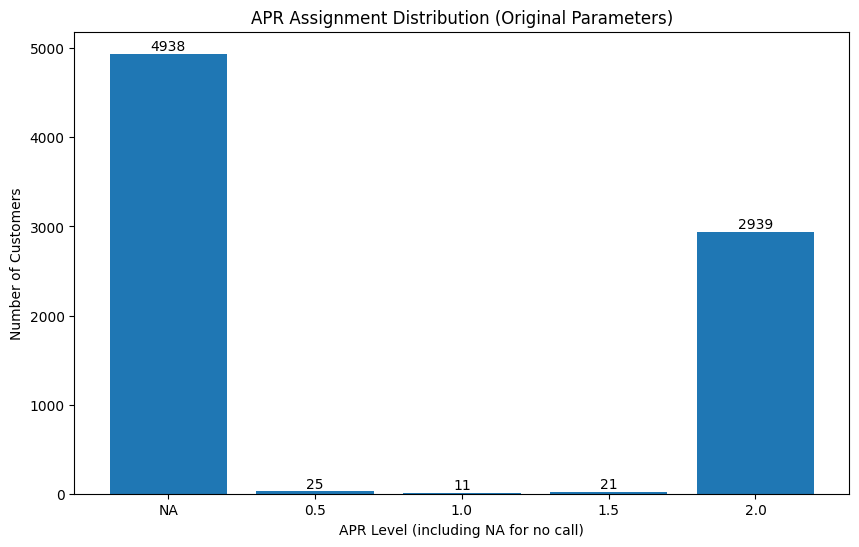


Running Sensitivity Analysis (Grid Search)...


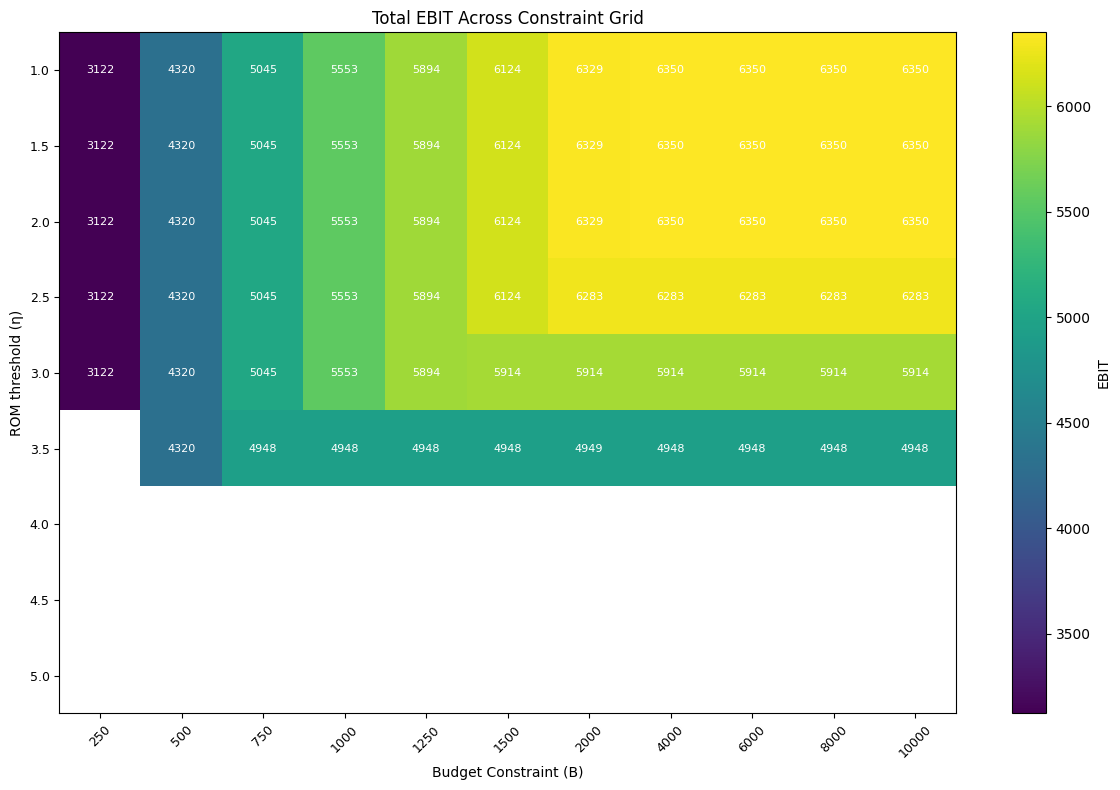

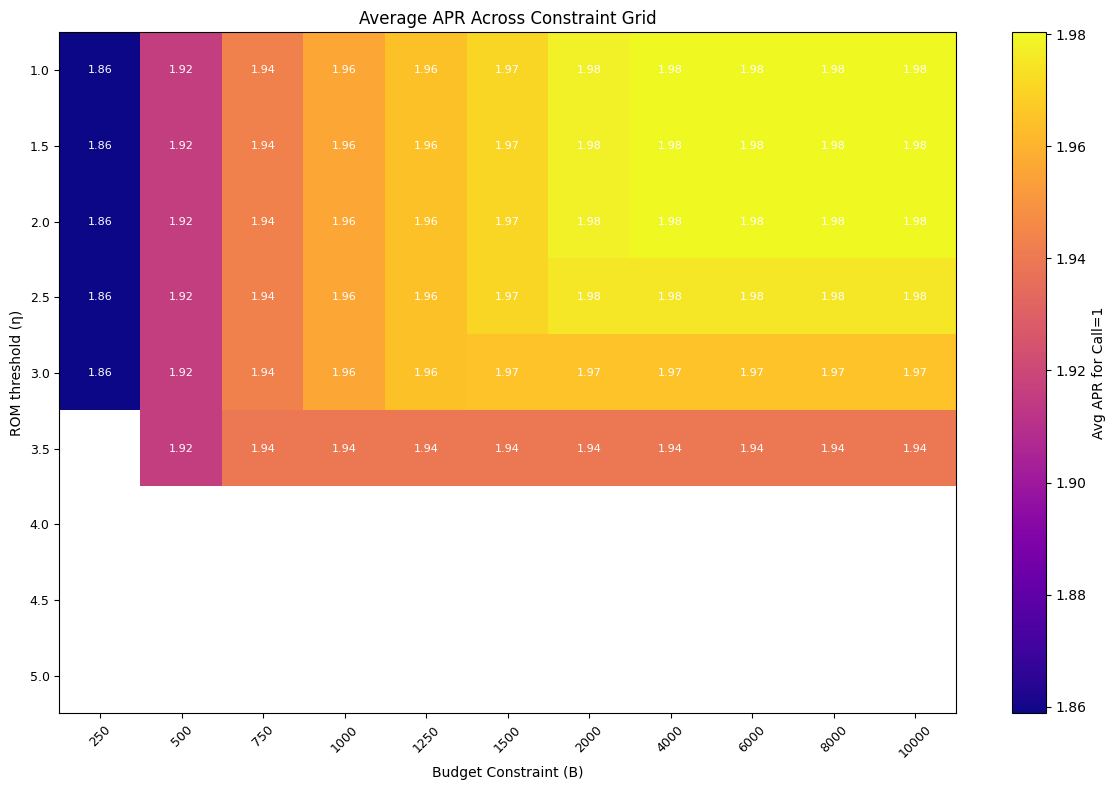


✅ ALL DONE! Final offers saved to C:\Users\ryan1\OneDrive\Desktop\IDS\FINAL_OPTIMAL_OFFERS.csv


In [6]:
# Run the full pipeline.
# Stage I generates the modeling outputs and decision grid.
# Stage II then solves the optimization problem using that decision grid.

main()
stage2_outputs = run_stage_2()

if stage2_outputs is not None:
    final_solution, EBIT_mat, APR_mat = stage2_outputs


## 8. Results Interpretation and Implementation Notes

After a successful run, the most important outputs are summarized below.

| Output file | Description |
|---|---|
| `t2_slice_sorted.csv` | Cross-sectional sample used for the decision problem |
| `synthesized_deposit_summary.csv` | Summary of synthesized deposit amounts |
| `deposit_model_comparison.csv` | Performance comparison for deposit prediction models |
| `conversion_model_evaluation_full.csv` | Logistic-regression conversion model performance |
| `decision_grid_fixed.csv` | Customer-offer grid used for optimization |
| `FINAL_OPTIMAL_OFFERS.csv` | Final optimized APR and call decision by customer |

The optimization results should be interpreted as expected values under the modeling assumptions. The main business implication is that customer targeting should be based on expected EBIT rather than conversion probability alone. A customer may be likely to convert but still generate limited value if the expected deposit amount is small, withdrawal risk is high, or the required offer is too expensive.

In practice, the bank should validate the recommended strategy through a pilot campaign. After observing realized conversion, deposit, and withdrawal outcomes, the prediction models and cost assumptions should be recalibrated before broader deployment.